# movie genre prediction model

## about
The main idea of this model is to take a movie, chop it into smaller chunks that can be processed by the ai. Than put the chunks into the model and calculate the average genre over them. This should result in a useable genre predicting ai model.

## problems
The biggest problem is the dataset. My current dataset consists of ~1.5TB of movies. That is less than its needed to use the whole video as a learning parameter.

## ai parameters
The ai input will be:
- motion between the frames (catch fast car scenes, fights or slow scenes)
- full audio of the frame (to catch guns/bombs, horror jumpscares or calm music etc...)
- average of the clips brightness (horrors are dark, romance movies are bright)
- average clip color (same use as clip brightness)

// not yet implemented / may confuse the model
- a few low resolution frames (mostly to catch the movie atmosphere)

The ai output will be:
- list of propabilities of genres
Each movie has multiple genres so the ai will output multiple values

## data collection phase
First the movie data must be collected. Movies were collected beforehand from unknown sources (the hard drives fell out of the sky). Movies were missing the genres and usefull info. So the info was retrieved from ČSFD by a open source javascript project [here](https://github.com/bartholomej/node-csfd-api).

## scraper logic
The scraper first processes the movie names and srips all information like resolution, dabbing and all things that are not part of the tittle. Because it can miss some junk the scraper tries to than find the best tittle match on ČSFD and propts the user whether its correct or not. The user can than change the movie id.

Code for the ČSFD scraper is here:
``` javascript
import { promises as fs } from 'fs';
import path from 'path';
import fastGlob from 'fast-glob';
import { csfd } from 'node-csfd-api';
import readline from 'readline';

const VIDEO_EXT = ['.mp4', '.mkv', '.avi', '.mov', '.wmv', '.flv'];
const FOLDER = path.resolve(process.argv[2]);
const OUTPUT_FILE = process.argv[3];

function normalizeName(filename) {
  let name = filename.replace(path.extname(filename), '');
  name = name.replace(/\[[^\]]+\]/g, '');
  name = name.replace(/\([^)]+\)/g, '');
  name = name.replace(
    /1080p|720p|2160p|BluRay|BRRip|WEBRip|HDRip|DVDRip|x264|x265|HEVC|AVC|CZ|EN/gi,
    ''
  );
  name = name.replace(/[_\.]/g, ' ');
  name = name.replace(/\s+/g, ' ').trim();
  return name;
}

function askQuestion(query) {
  const rl = readline.createInterface({
    input: process.stdin,
    output: process.stdout
  });
  return new Promise(resolve =>
    rl.question(query, ans => {
      rl.close();
      resolve(ans);
    })
  );
}

async function processFiles() {
  const files = await fastGlob(`${FOLDER}/**/*`, { onlyFiles: true });
  await fs.writeFile(OUTPUT_FILE, '');

  for (const filePath of files) {
    const ext = path.extname(filePath).toLowerCase();
    if (!VIDEO_EXT.includes(ext)) continue;

    const filename = path.basename(filePath);
    const searchName = normalizeName(filename);
    if (!searchName) continue;

    console.log(`searching: ${searchName}`);

    try {
      const results = await csfd.search(searchName);
      const movies = results.movies ?? [];

      if (movies.length === 0) {
        console.log('no match found');
        continue;
      }

      const bestMatch = movies[0];
      const movieDetail = await csfd.movie(bestMatch.id);

      console.log(`found: ${movieDetail.title} (${movieDetail.year})`);
      console.log(`csfd id: ${movieDetail.id}`);

      const userInput = await askQuestion(
        'press enter to confirm or type csfd id: '
      );

      let csfd_id = bestMatch.id;
      if (userInput.trim()) {
        csfd_id = userInput.trim();
      }

      const relativePath = path.relative(FOLDER, filePath);

      const outputEntry = {
        file_path: relativePath,
        csfd_id: csfd_id,
        title: movieDetail.title,
        year: movieDetail.year,
        genres: movieDetail.genres
      };

      await fs.appendFile(
        OUTPUT_FILE,
        JSON.stringify(outputEntry) + '\n'
      );

      console.log(`saved: ${filename} -> csfd id: ${csfd_id}`);

    } catch (err) {
      console.error(`error for ${filename}:`, err.message);
    }
  }

  console.log('\ndone!');
}

processFiles();
```

## Chopper
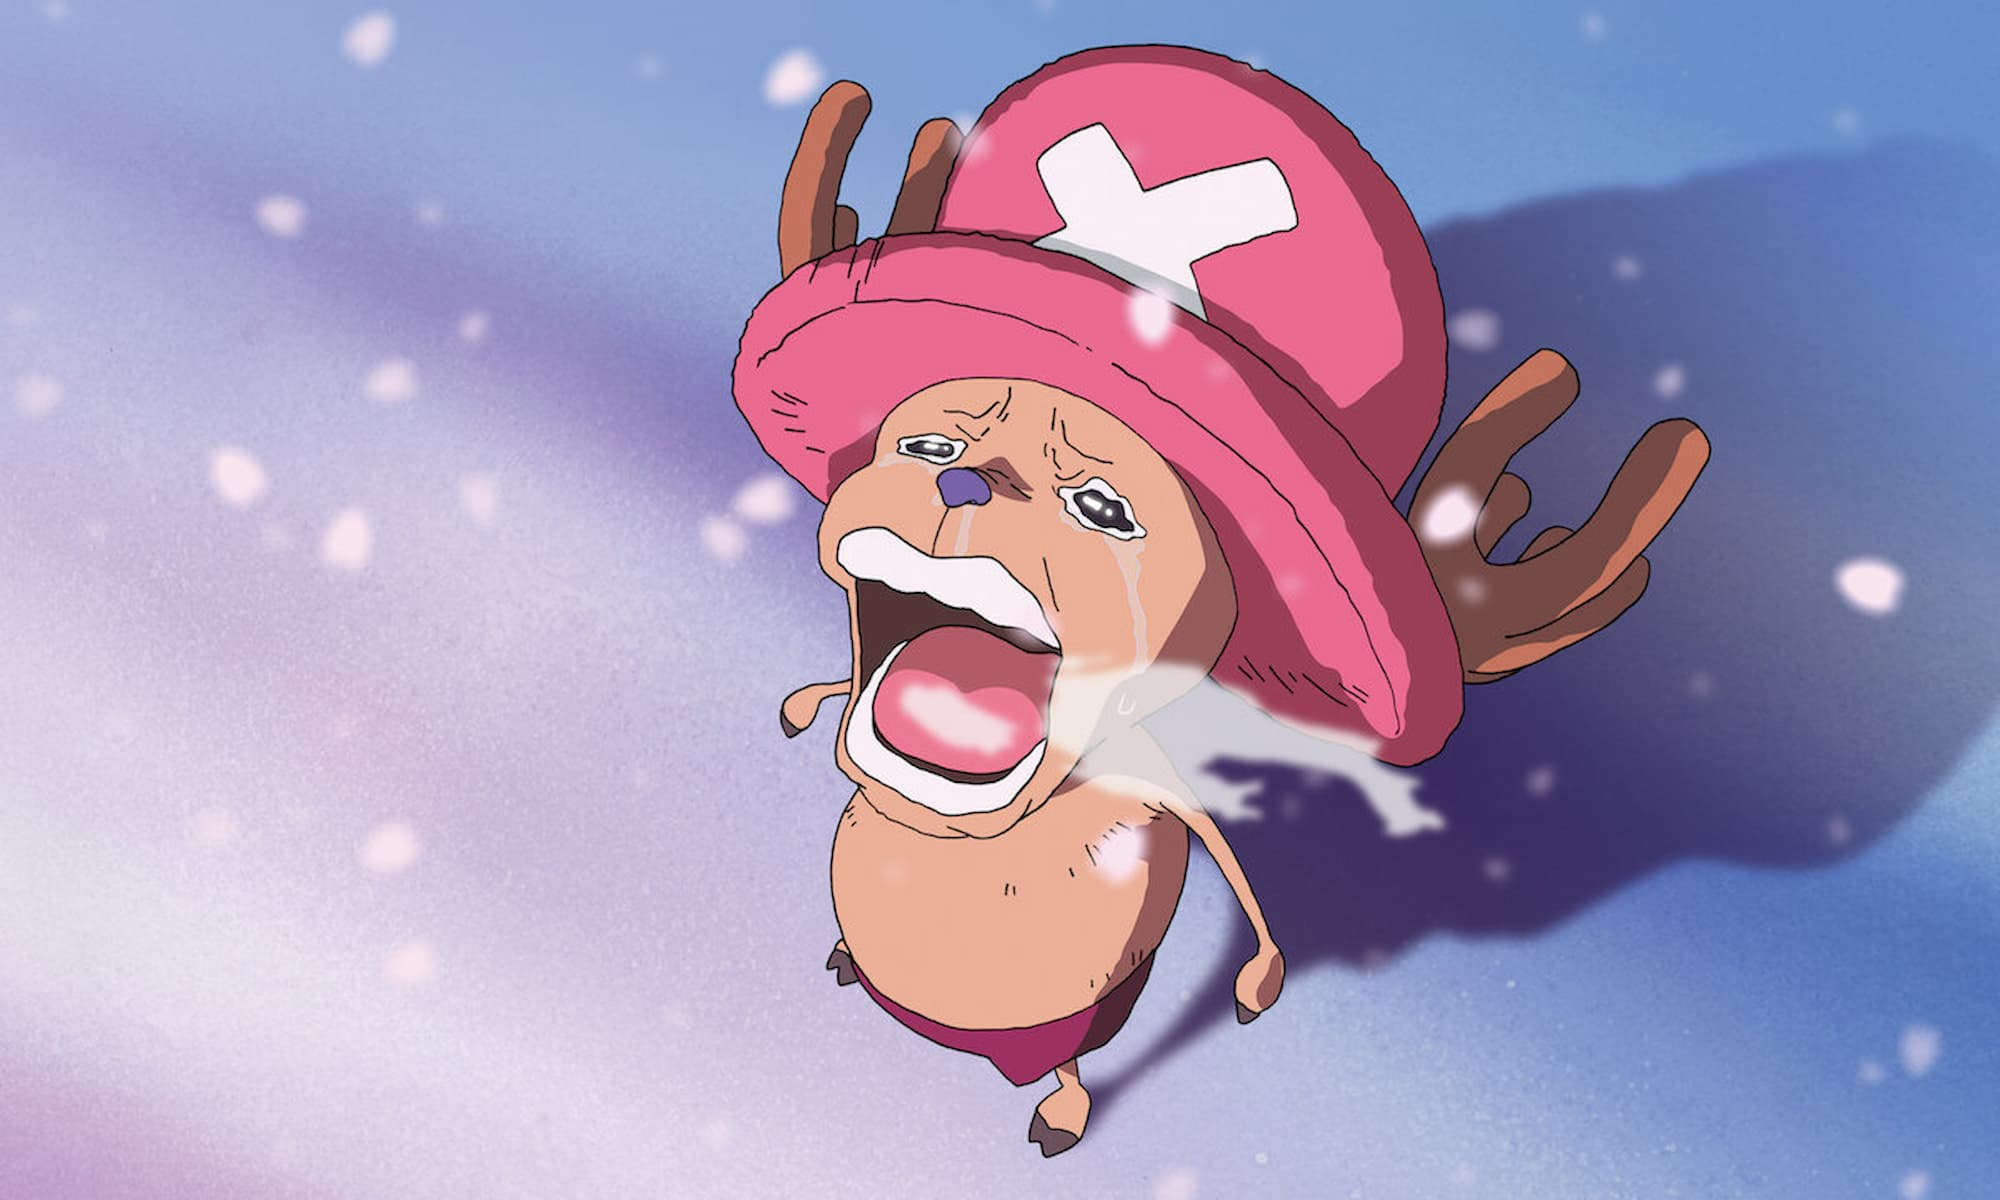

The chopper takes the output of the scraper and cuts the movie into approximately 10 minute clips the code is written below.
The chopper tries to copy the movie stream but if it fails it tries to reencode the movie in a very low quality compression. This is because on an old pentium duo pc that i was running this on had problem with copying of some movies. Also a gpu accelerated version was written, but i wont paste it here.

In [ ]:
import os
import json
import argparse
import subprocess
import re
from multiprocessing import Pool, cpu_count

parser = argparse.ArgumentParser()
parser.add_argument("jsonl_file", help="input from the scraper")
parser.add_argument("output_dir", help="where to store the clips")
parser.add_argument("dataset_jsonl", help="metadata of the clips")
parser.add_argument("--base-dir", required=True, help="base directory to resolve relative input video paths")
parser.add_argument("--workers", type=int, default=cpu_count(), help="number of parallel workers")
args = parser.parse_args()

os.makedirs(args.output_dir, exist_ok=True)

clip_duration = 600  # 10 minutes
base_dir = os.path.abspath(args.base_dir)
output_dir_abs = os.path.abspath(args.output_dir)


def safe_name(name):
    return re.sub(r'[^\w\-_\. ]', '_', name)


def reencode_and_segment(video_input, output_pattern):
    def run_ffmpeg(cmd):
        return subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True, preexec_fn=lambda: os.nice(10))

    try:
        run_ffmpeg([
            "ffmpeg", "-y", "-i", video_input,
            "-c", "copy", "-f", "segment",
            "-segment_time", str(clip_duration),
            "-reset_timestamps", "1",
            output_pattern
        ])
        return "copy"
    except subprocess.CalledProcessError:
        pass  
    
    try:
        run_ffmpeg([
            "ffmpeg", "-y",
            "-i", video_input,
            "-c:v", "libx264",
            "-preset", "ultrafast", "-crf", "28",
            "-c:a", "aac", "-b:a", "128k",
            "-f", "segment", "-segment_time", str(clip_duration),
            "-reset_timestamps", "1",
            output_pattern
        ])
        return "reencode"
    except subprocess.CalledProcessError:
        return None


def process_movie(film, dataset_jsonl_path, output_dir_abs, base_dir):
    safe_title = safe_name(film['title'])
    folder_name = f"{safe_title} ({film['year']})"
    folder_path = os.path.join(output_dir_abs, folder_name)
    os.makedirs(folder_path, exist_ok=True)

    video_input = film['file_path']
    if not os.path.isabs(video_input):
        video_input = os.path.join(base_dir, video_input)
    video_input = os.path.abspath(video_input)

    if not os.path.isfile(video_input):
        print(f"video not found: {video_input}")
        return 0
    
    print(f"processing video: {video_input}")

    output_pattern = os.path.join(folder_path, f"{safe_title}_{film['year']}_%03d.mkv")

    result = reencode_and_segment(video_input, output_pattern)
    if result == "copy":
        print(f"success (stream copy): {film['title']}")
    elif result == "reencode":
        print(f"success (reencode): {film['title']}")
    else:
        print(f"failed: {film['title']}")
        return 0

    video_extensions = (".mkv", ".mp4", ".mov", ".avi", ".flv", ".wmv", ".m4v", ".webm")
    clips = sorted(
        f for f in os.listdir(folder_path)
        if f.lower().endswith(video_extensions)
    )
    count = 0
    with open(dataset_jsonl_path, 'a', encoding='utf-8') as out_f:
        for clip_file in clips:
            clip_path_abs = os.path.join(folder_path, clip_file)
            clip_path_rel = os.path.relpath(clip_path_abs, output_dir_abs)
            entry = {
                "csfd_id": film.get("csfd_id"),
                "title": film.get("title"),
                "year": film.get("year"),
                "genres": film.get("genres", []),
                "clip_path": clip_path_rel
            }
            json.dump(entry, out_f, ensure_ascii=False)
            out_f.write('\n')
            count += 1
    return count


def main():
    movies = []
    with open(args.jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                movies.append(json.loads(line))

    total_clips = 0
    dataset_jsonl_path = args.dataset_jsonl

    open(dataset_jsonl_path, 'w').close()

    with Pool(processes=args.workers) as pool:
        results = pool.starmap(
            process_movie,
            [(film, dataset_jsonl_path, output_dir_abs, base_dir) for film in movies]
        )
        total_clips = sum(results)
    
    print(f"total clips processed: {total_clips}")


if __name__ == "__main__":
    main()


## dataset loading and cleanup



In [ ]:
### imports

Here are all used libraries for the code

In [3]:
import json
import os
import pandas as pd
# import cupy as cp
# import cv2

import ffmpeg
import librosa

### utility

Before writing the dataset cleanup code there are some untilities that could be helpfull.

Because video processing is very slow, the dataset can be saved into a jsonl format to make it not recalculate everything again.


In [4]:
def dataset_save(dataset, jsonl_path):
    dataset.to_json(jsonl_path, orient='records', lines=True)

def dataset_load(jsonl_path):
    jsonl_file = open(jsonl_path, "r", encoding="utf-8")
    dataset = pd.read_json(jsonl_file, lines=True)
    jsonl_file.close()
    return dataset

Click these cells to load or save the dataset

In [6]:
dataset_save(dataset, "genre_ai_dataset.jsonl")

In [ ]:
dataset = dataset_load("genre_ai_dataset.jsonl")

### dataset load

There were multiple phases of movie processing each outputting its own metadata and directory. Therefore its needed to load and merge all dataset pieces into one.

In [5]:
dataset_paths = [
     # movie dataset directory
    ('/mnt/hdd/dataset/chopped/Milan')
]

data_frames = []

for dataset_path in dataset_paths:
    jsonl_path = os.path.join(dataset_path, 'dataset.jsonl')
    jsonl_file = open(jsonl_path, "r", encoding="utf-8")
    data_frame = pd.read_json(jsonl_file, lines=True)
    jsonl_file.close()

    # make clip_path absolute
    data_frame["clip_path"] = data_frame["clip_path"].apply(
        lambda x: os.path.abspath(os.path.join(dataset_path, x))
    )

    data_frames.append(data_frame)

dataset = pd.concat(data_frames, ignore_index=True)

dataset.head()

,csfd_id,title,year,genres,clip_path
0,4742,Mrtvý muž,1995,"[Western, Drama, Fantasy]",/mnt/hdd/dataset/chopped/Milan/Mrtvý muž (1995...
1,4742,Mrtvý muž,1995,"[Western, Drama, Fantasy]",/mnt/hdd/dataset/chopped/Milan/Mrtvý muž (1995...
2,4742,Mrtvý muž,1995,"[Western, Drama, Fantasy]",/mnt/hdd/dataset/chopped/Milan/Mrtvý muž (1995...
3,4742,Mrtvý muž,1995,"[Western, Drama, Fantasy]",/mnt/hdd/dataset/chopped/Milan/Mrtvý muž (1995...
4,4742,Mrtvý muž,1995,"[Western, Drama, Fantasy]",/mnt/hdd/dataset/chopped/Milan/Mrtvý muž (1995...


### video motion processing

The when the dataset is loaded we can process the video clips.

First some global variables need to be set up.

In [ ]:
# resolution to work with
# its smaller for faster processing
width = 256
height = 144
segments = 32 # number of values to get from each video clip

Because i have a nvidia gpu that supports cuda. All computations that support cuda gpu acceleration use it. This will make this code run only on nvidia gpus but way faster.

CuPy is used instead of NumPy, it has the same API but its uses the gpu cuda cores.

The video data will be calculated in the same function, to reduce disk load times.
The function below calculates the color average, motion and brightness.

In [ ]:


def process_video(video_path):
    global width
    global height
    global segments
    
    capture = cv2.VideoCapture(video_path)
    if not capture.isOpened():
        raise RuntimeError(f"cannot open video: {video_path}")
    
    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < segments+1:
        frames_to_check = list(range(total_frames))
    else:
        frames_to_check = [int(i * total_frames / (segments+1)) for i in range(segments+1)]
    
    capture.set(cv2.CAP_PROP_POS_FRAMES, frames_to_check.pop(0))
    ret, prev_frame = capture.read()
    if not ret:
        capture.release()
        raise Exception("failed to read the first frame")

    prev_frame = cv2.resize(prev_frame, (width, height))
    
    prev_gpu = cv2.cuda_GpuMat()
    prev_gpu.upload(prev_frame)
    prev_gray_gpu = cv2.cuda.cvtColor(prev_gpu, cv2.COLOR_BGR2GRAY)

    motion_values = []
    brightness_values = []
    avg_color_values = []
        
    for frame_index in frames_to_check:
        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ret, frame = capture.read()
        if not ret:
            raise Exception("failed to read a frame, data would be invalid")
        
        frame = cv2.resize(frame, (width, height))

        frame_gpu = cv2.cuda_GpuMat()
        frame_gpu.upload(frame)
        gray_gpu = cv2.cuda.cvtColor(frame_gpu, cv2.COLOR_BGR2GRAY)
        
        # motion
        diff_gpu = cv2.cuda.absdiff(prev_gray_gpu, gray_gpu)
        diff_cp = cp.asarray(diff_gpu.download())
        motion_values.append(float(cp.mean(diff_cp)))
        
        # brightness
        gray_cp = cp.asarray(gray_gpu.download())
        brightness_values.append(float(cp.mean(gray_cp)))

        # color avg
        frame_cp = cp.asarray(frame_gpu.download())
        avg_b = float(cp.mean(frame_cp[:, :, 0]))
        avg_g = float(cp.mean(frame_cp[:, :, 1]))
        avg_r = float(cp.mean(frame_cp[:, :, 2]))
        avg_color_values.append((avg_b, avg_g, avg_r))
        
        prev_gray_gpu = gray_gpu

    capture.release()
    return pd.DataFrame({
        "motion": motion_values,
        "brightness": brightness_values,
        "avg_color": avg_color_values
    })

# merge into the dataset

results = []

for _, row in dataset.iterrows():
    clip_path = row["clip_path"]
    df = process_video(clip_path)
    
    results.append({
        "clip_path": clip_path,
        "motion": df["motion"],
        "brightness": df["brightness"],
        "abg_color": df["avg_color"]
    })

motion_brightness_df = pd.DataFrame(results)

dataset = dataset.merge(motion_brightness_df, on="clip_path", how="left")

dataset.head()

### audio

The video clip will be chopped into smaller pieces and average audio values will be recorded. The audio is split into "segments" of values. "segments" is the variable defined when processing video.

First some globals need to be set.

In [ ]:
audio_sample_rate = 8000

In [ ]:


def process_audio(video_path):
    global segments
    global audio_sample_rate
    
    out, _ = (
        ffmpeg
        .input(video_path)
        .output('pipe:', format='f32le', acodec='pcm_f32le', ac=1, ar=audio_sample_rate)
        .run(capture_stdout=True, capture_stderr=True)
    )
    
    y = np.frombuffer(out, np.float32)
    total_samples = len(y)
    
    segment_size = total_samples // segments
    rms_values = []
    amp_values = []
    mfcc_values = []
    
    for i in range(segments):
        start = i * segment_size
        end = start + segment_size if i < segments - 1 else total_samples
        segment = y[start:end]
        
        rms = np.sqrt(np.mean(segment**2))
        amp_mean = np.mean(segment)
        mfccs = librosa.feature.mfcc(y=segment, sr=audio_sample_rate, n_mfcc=13)
        mfcc_mean = np.mean(mfccs, axis=1)
        
        rms_values.append(rms)
        amp_values.append(amp_mean)
        mfcc_values.append(mfcc_mean)
    
    return pd.DataFrame({
            "audio_amplitude": amp_values,
            "audio_rms": rms_values,
            "audio_mfcc": mfcc_values
    })

# merge into the dataset

results = []

for _, row in dataset.iterrows():
    clip_path = row["clip_path"]
    df = process_audio(clip_path)
    
    results.append({
        "clip_path": clip_path,
        "audio_amplitude": df["audio_amplitude"],
        "audio_rms": df["audio_rms"],
        "audio_mfcc": df["audio_mfcc"]
    })

motion_brightness_df = pd.DataFrame(results)

dataset = dataset.merge(motion_brightness_df, on="clip_path", how="left")

dataset.head()